<a href="https://colab.research.google.com/github/ChanggonSong/AI-Study/blob/main/diabetes_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [35]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [36]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/diabetes.csv', index_col=0)
df.head()

,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,,,,,,,,
6,148,72,35,0,33.6,0.627,50,1
1,85,66,29,0,26.6,0.351,31,0
8,183,64,0,0,23.3,0.672,32,1
1,89,66,23,94,28.1,0.167,21,0
0,137,40,35,168,43.1,2.288,33,1


In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 768 entries, 6 to 1
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Glucose                   768 non-null    int64  
 1   BloodPressure             768 non-null    int64  
 2   SkinThickness             768 non-null    int64  
 3   Insulin                   768 non-null    int64  
 4   BMI                       768 non-null    float64
 5   DiabetesPedigreeFunction  768 non-null    float64
 6   Age                       768 non-null    int64  
 7   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(6)
memory usage: 54.0 KB


In [38]:
df.describe()

,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [39]:
# 결측치 확인
df.isnull().sum()

Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [40]:
# 결측치 제거
df = df.dropna()
df.isnull().sum()

Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

<Axes: xlabel='Outcome', ylabel='count'>

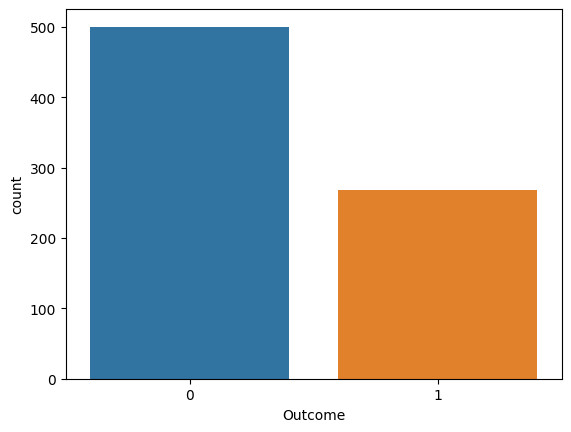

In [41]:
sns.countplot(data=df, x="Outcome")

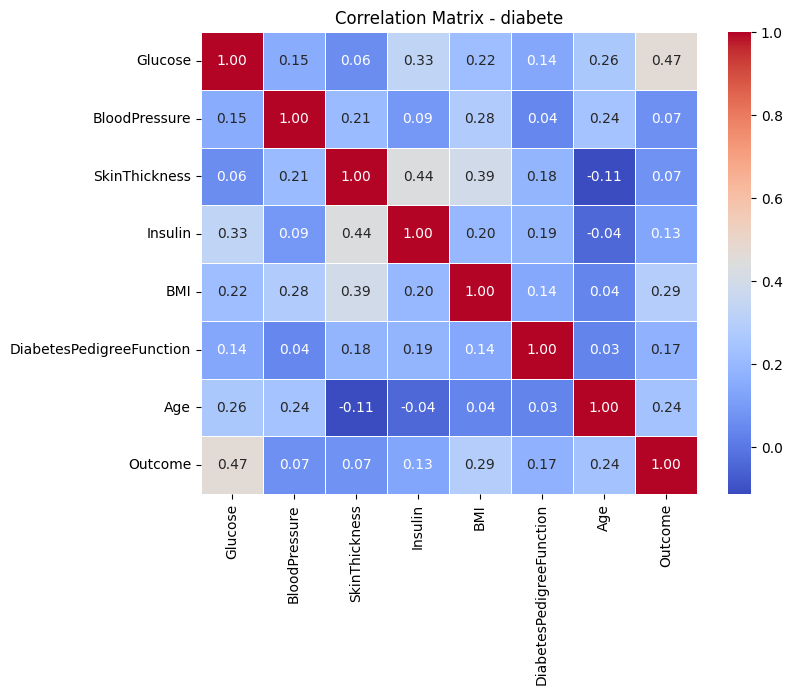

In [42]:
correlation_matrix = df[['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']].corr()

# 히트맵 그리기
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix - diabete')
plt.show()

# Outcome와 상관성이 강한 것: Glucose

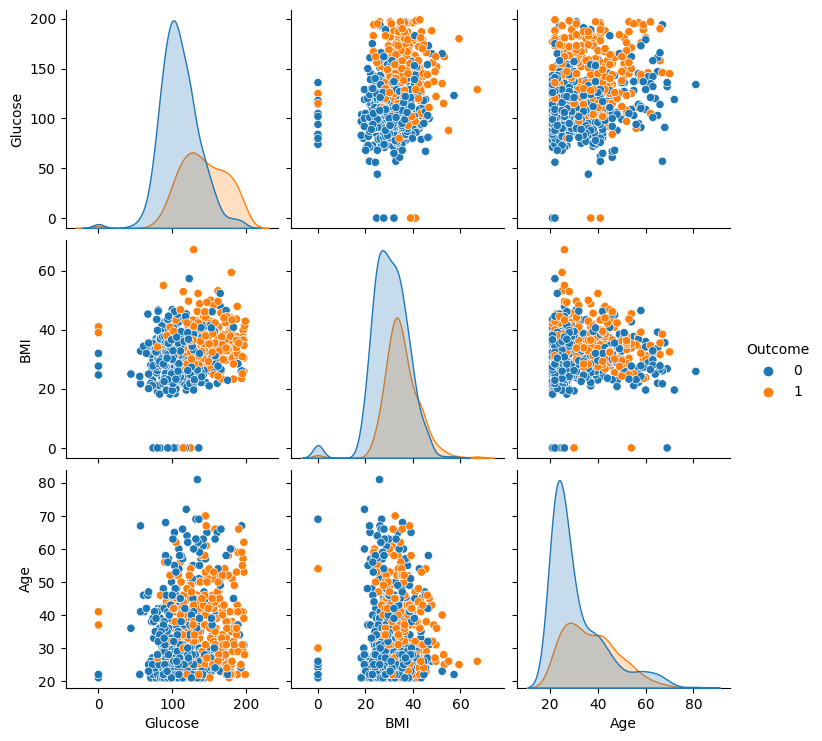

In [148]:
sns.pairplot(df, vars=['Glucose', 'BMI', 'Age'], hue ='Outcome')
plt.show()

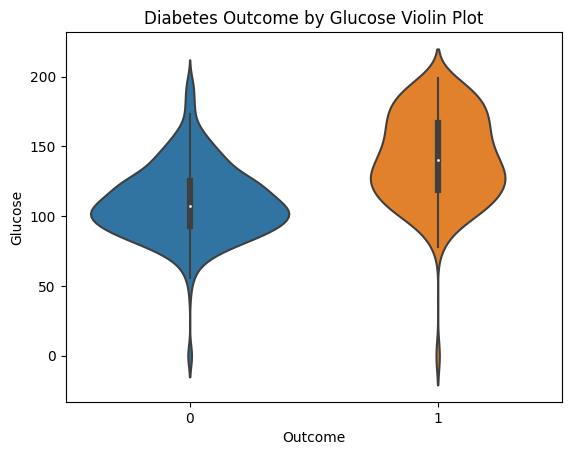

In [43]:
sns.violinplot(x="Outcome", y="Glucose", data=df)
plt.title("Diabetes Outcome by Glucose Violin Plot")
plt.show()

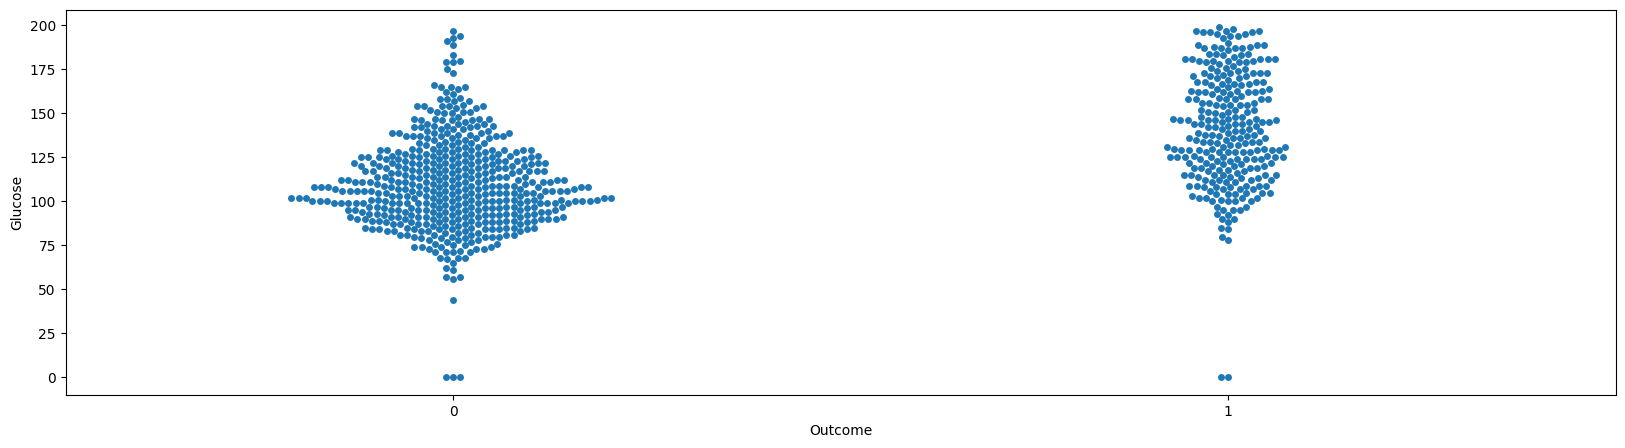

In [44]:
plt.figure(figsize=(20,5))
sns.swarmplot(x="Outcome", y="Glucose", data=df)
plt.show()

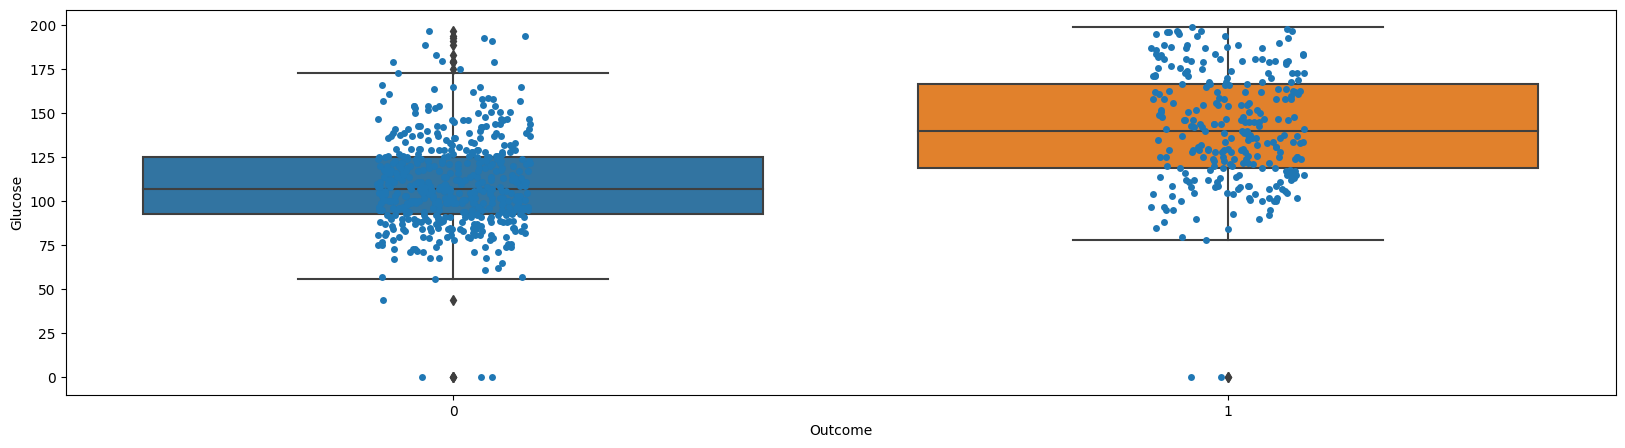

In [45]:
plt.figure(figsize=(20,5))
sns.boxplot(x="Outcome", y="Glucose", data=df)
sns.stripplot(x="Outcome", y="Glucose", data=df, jitter=True)
plt.show()

In [46]:
y = df["Outcome"]
y

Pregnancies
6     1
1     0
8     1
1     0
0     1
     ..
10    0
2     0
5     0
1     1
1     0
Name: Outcome, Length: 768, dtype: int64

In [149]:
# 상관성 약한 것
columns_to_drop = ['Outcome', 'BloodPressure', 'SkinThickness', 'Insulin']
X = df.drop(columns=columns_to_drop, axis=1)
X

,Glucose,BMI,DiabetesPedigreeFunction,Age
Pregnancies,,,,
6,148,33.6,0.627,50
1,85,26.6,0.351,31
8,183,23.3,0.672,32
1,89,28.1,0.167,21
0,137,43.1,2.288,33
...,...,...,...,...
10,101,32.9,0.171,63
2,122,36.8,0.340,27
5,121,26.2,0.245,30


In [150]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=0)

In [178]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix

In [179]:
from sklearn.svm import SVC

clf_svm = SVC(random_state=0)
clf_svm.fit(X_train, y_train)

pred_svm = clf_svm.predict(X_test)

print("\n--- SVM Classifier ---")
print(accuracy_score(y_test, pred_svm))
print(confusion_matrix(y_test, pred_svm))


--- SVM Classifier ---
0.7857142857142857
[[97 10]
 [23 24]]


In [180]:
from sklearn.linear_model import LogisticRegression
clf_lr = LogisticRegression(random_state=0)
clf_lr.fit(X_train, y_train)

pred_lr = clf_lr.predict(X_test)

print ("\n--- Logistic Regression Classifier ---")
print (accuracy_score(y_test, pred_lr))
print (confusion_matrix(y_test, pred_lr))


--- Logistic Regression Classifier ---
0.7987012987012987
[[94 13]
 [18 29]]


In [181]:
from sklearn.neural_network import MLPClassifier
clf_nn = MLPClassifier(random_state=0)
clf_nn.fit(X_train, y_train)

pred_nn = clf_nn.predict(X_test)

print ("\n--- Neural Network Classifier ---")
print (accuracy_score(y_test, pred_nn))
print (confusion_matrix(y_test, pred_nn))


--- Neural Network Classifier ---
0.7662337662337663
[[97 10]
 [26 21]]


In [182]:
from sklearn.tree import DecisionTreeClassifier
clf_dt = DecisionTreeClassifier(random_state=0)
clf_dt.fit(X_train, y_train)

pred_dt = clf_dt.predict(X_test)

print ("\n--- Decision Tree Classifier ---")
print (accuracy_score(y_test, pred_dt))
print (confusion_matrix(y_test, pred_dt))


--- Decision Tree Classifier ---
0.7402597402597403
[[83 24]
 [16 31]]


In [183]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

print ("\n--- Radom Forest ---")
rf_clf = RandomForestClassifier(random_state=0)
rf_clf.fit(X_train, y_train)
pred = rf_clf.predict(X_test)
print(accuracy_score(y_test,pred))
print (confusion_matrix(y_test, pred))


--- Radom Forest ---
0.7857142857142857
[[91 16]
 [17 30]]


교차 검증, StratifiedKFold

In [184]:
X_train.shape

(614, 4)

In [185]:
X_sub, X_val, y_sub, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42)

In [186]:
print(X_sub.shape, X_val.shape)

(491, 4) (123, 4)


In [187]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_sub, y_sub)

print(dt.score(X_sub, y_sub))
print(dt.score(X_val, y_val))
#과대 적합

1.0
0.6422764227642277


In [188]:
from sklearn.model_selection import GridSearchCV
params = {'min_impurity_decrease': [0.0001, 0.0002, 0.0003, 0.0004, 0.0005]}

gs = GridSearchCV(DecisionTreeClassifier(random_state=42), params, n_jobs=-1)
gs.fit(X_train, y_train)

GridSearchCV(estimator=DecisionTreeClassifier(random_state=42), n_jobs=-1,
             param_grid={'min_impurity_decrease': [0.0001, 0.0002, 0.0003,
                                                   0.0004, 0.0005]})

In [189]:
dt = gs.best_estimator_
print(dt.score(X_train, y_train))

0.993485342019544


In [190]:
print(gs.best_params_)

{'min_impurity_decrease': 0.0004}


In [191]:
print(gs.cv_results_['mean_test_score'])

[0.68405971 0.68405971 0.69706784 0.69869386 0.69059043]


In [192]:
best_index = np.argmax(gs.cv_results_['mean_test_score'])
print(gs.cv_results_['params'][best_index])

{'min_impurity_decrease': 0.0004}


In [193]:
params = {'min_impurity_decrease': np.arange(0.0001, 0.001, 0.0001),
          'max_depth': range(5, 20, 1),
          'min_samples_split': range(2, 100, 10)
          }

In [194]:
gs = GridSearchCV(DecisionTreeClassifier(random_state=42), params, n_jobs=-1)
gs.fit(X_train, y_train)

GridSearchCV(estimator=DecisionTreeClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': range(5, 20),
                         'min_impurity_decrease': array([0.0001, 0.0002, 0.0003, 0.0004, 0.0005, 0.0006, 0.0007, 0.0008,
       0.0009]),
                         'min_samples_split': range(2, 100, 10)})

In [195]:
print(gs.best_params_)

{'max_depth': 6, 'min_impurity_decrease': 0.0001, 'min_samples_split': 72}


In [196]:
print(np.max(gs.cv_results_['mean_test_score']))

0.7328935092629616


###랜덤 서치

In [197]:
from scipy.stats import uniform, randint
rgen = randint(0, 10)
rgen.rvs(10)

array([6, 9, 6, 6, 4, 6, 0, 4, 5, 5])

In [198]:
np.unique(rgen.rvs(1000), return_counts=True)

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]),
 array([ 95,  93,  86, 101, 129,  94,  97, 105, 103,  97]))

In [199]:
ugen = uniform(0, 1)
ugen.rvs(10)

array([0.97398651, 0.22938184, 0.39502163, 0.4312569 , 0.74677445,
       0.35620447, 0.45681406, 0.11760988, 0.36633275, 0.73228364])

In [200]:
params = {'min_impurity_decrease': uniform(0.0001, 0.001),
          'max_depth': randint(20, 50),
          'min_samples_split': randint(2, 25),
          'min_samples_leaf': randint(1, 25),
          }

In [201]:
from sklearn.model_selection import RandomizedSearchCV

gs = RandomizedSearchCV(DecisionTreeClassifier(random_state=42), params,
                        n_iter=100, n_jobs=-1, random_state=42)
gs.fit(X_train, y_train)

RandomizedSearchCV(estimator=DecisionTreeClassifier(random_state=42),
                   n_iter=100, n_jobs=-1,
                   param_distributions={'max_depth': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7ef709a5ea40>,
                                        'min_impurity_decrease': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7ef70b9d2ad0>,
                                        'min_samples_leaf': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7ef70ba4b310>,
                                        'min_samples_split': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7ef70b9d13c0>},
                   random_state=42)

In [202]:
print(gs.best_params_) #최적의 매개변수 조합

{'max_depth': 43, 'min_impurity_decrease': 0.00011407982271508446, 'min_samples_leaf': 19, 'min_samples_split': 18}


In [203]:
print(np.max(gs.cv_results_['mean_test_score'])) # 교차검증 최고 점수

0.7377582300413168


In [211]:
dt = gs.best_estimator_

print(dt.score(X_test, y_test))

0.7792207792207793


In [212]:
# PolynomialFeature을 적용
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=5,include_bias=False)
poly.fit(X_sub)
train_poly = poly.transform(X_sub)
print(train_poly.shape)

(491, 125)


In [213]:
test_poly = poly.transform(X_test)

In [222]:
from sklearn.preprocessing import StandardScaler
ss = StandardScaler()
ss.fit(train_poly)
train_scaled = ss.transform(train_poly)
test_scaled = ss.transform(test_poly)

In [223]:
clf_svm = SVC(random_state=0)
clf_svm.fit(train_scaled, y_sub)

pred_svm = clf_svm.predict(test_scaled)

print("\n--- SVM Classifier ---")
print(accuracy_score(y_test, pred_svm))
print(confusion_matrix(y_test, pred_svm))


--- SVM Classifier ---
0.7792207792207793
[[95 12]
 [22 25]]
